# E-Commerce Support Chatbot — Exploratory Data Analysis

**Dataset:** [Bitext Customer Support LLM Chatbot Training Dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset)  
**Objective:** Understand intent distribution, class imbalance, and query characteristics to inform model training decisions.

### Key Questions
1. How are intents distributed? Is there class imbalance?
2. What is the typical query length? Does it vary by intent?
3. Which intents are most similar (potential confusion)?
4. What class weighting strategy should we use for training?

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

## 1. Load Processed Data

In [2]:
def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train = read_jsonl("../data/processed/train.jsonl")
val   = read_jsonl("../data/processed/val.jsonl")
test  = read_jsonl("../data/processed/test.jsonl")

print(f"Train: {len(train):,}  |  Val: {len(val):,}  |  Test: {len(test):,}")
print(f"Total: {len(train)+len(val)+len(test):,}")

# Combine for full EDA
all_data = train + val + test
df = pd.DataFrame(all_data)
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()
df.head()

Train: 21,497  |  Val: 2,687  |  Test: 2,688
Total: 26,872


,text,label,word_count,char_count
0,I want assistance informing of a trouble with ...,payment_issue,9,53
1,see bill #12588,check_invoice,3,15
2,"I want to see my refund current status, help me",track_refund,10,47
3,see current status of order ORDER_ID,track_order,6,36
4,"I need to check the options for shipping, how ...",delivery_options,13,57


## 2. Intent Distribution

Understanding which intents are common vs rare directly informs our **class weighting** strategy during training.

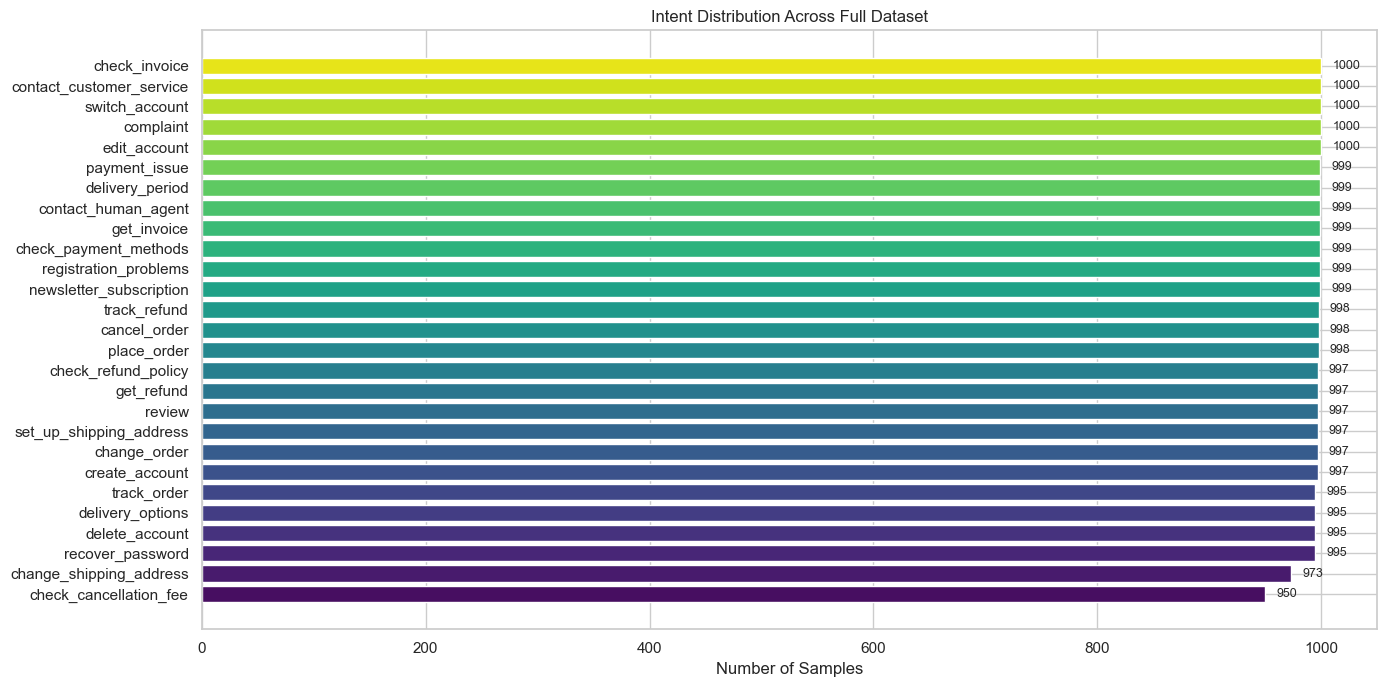


Number of unique intents: 27
Most common:  check_invoice (1000)
Least common: check_cancellation_fee (950)
Imbalance ratio: 1.05x


In [3]:
intent_counts = df["label"].value_counts()

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(intent_counts.index[::-1], intent_counts.values[::-1], color=sns.color_palette("viridis", len(intent_counts)))
ax.set_xlabel("Number of Samples")
ax.set_title("Intent Distribution Across Full Dataset")

# Add count labels on bars
for bar, count in zip(bars, intent_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
            str(count), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../artifacts/eval_results/intent_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nNumber of unique intents: {len(intent_counts)}")
print(f"Most common:  {intent_counts.index[0]} ({intent_counts.values[0]})")
print(f"Least common: {intent_counts.index[-1]} ({intent_counts.values[-1]})")
print(f"Imbalance ratio: {intent_counts.values[0] / intent_counts.values[-1]:.2f}x")

## 3. Class Imbalance Analysis

If the imbalance ratio is significant, we use **inverse-frequency class weights** in `CrossEntropyLoss` so the model doesn't ignore rare intents.

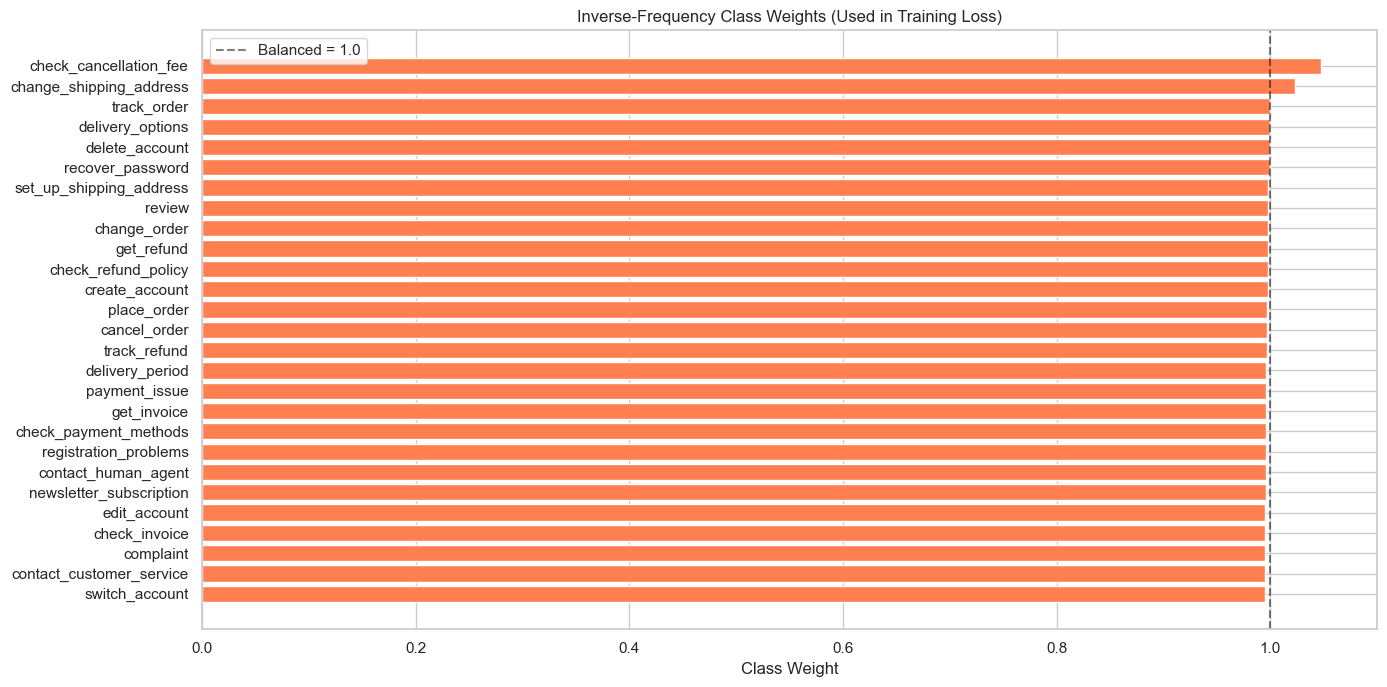

                  intent  count  class_weight
  check_cancellation_fee    950      1.047641
 change_shipping_address    973      1.022877
             track_order    995      1.000261
        delivery_options    995      1.000261
          delete_account    995      1.000261
        recover_password    995      1.000261
 set_up_shipping_address    997      0.998254
                  review    997      0.998254
            change_order    997      0.998254
              get_refund    997      0.998254
     check_refund_policy    997      0.998254
          create_account    997      0.998254
             place_order    998      0.997254
            cancel_order    998      0.997254
            track_refund    998      0.997254
         delivery_period    999      0.996256
           payment_issue    999      0.996256
             get_invoice    999      0.996256
   check_payment_methods    999      0.996256
   registration_problems    999      0.996256
     contact_human_agent    999   

In [4]:
# Compute class weights (same formula used in train_intent_gru.py)
total = len(df)
num_classes = len(intent_counts)
weights = {}
for intent, count in intent_counts.items():
    weights[intent] = total / (num_classes * count)

weight_df = pd.DataFrame({
    "intent": weights.keys(),
    "count": [intent_counts[k] for k in weights.keys()],
    "class_weight": weights.values()
}).sort_values("class_weight", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(weight_df["intent"][::-1], weight_df["class_weight"][::-1], color="coral")
ax.set_xlabel("Class Weight")
ax.set_title("Inverse-Frequency Class Weights (Used in Training Loss)")
ax.axvline(x=1.0, color="black", linestyle="--", alpha=0.5, label="Balanced = 1.0")
ax.legend()
plt.tight_layout()
plt.savefig("../artifacts/eval_results/class_weights.png", dpi=150, bbox_inches="tight")
plt.show()

print(weight_df.to_string(index=False))

## 4. Query Length Analysis

Understanding query length helps set `MAX_LEN` for tokenization (currently 40 tokens) and reveals if some intents naturally produce longer/shorter queries.

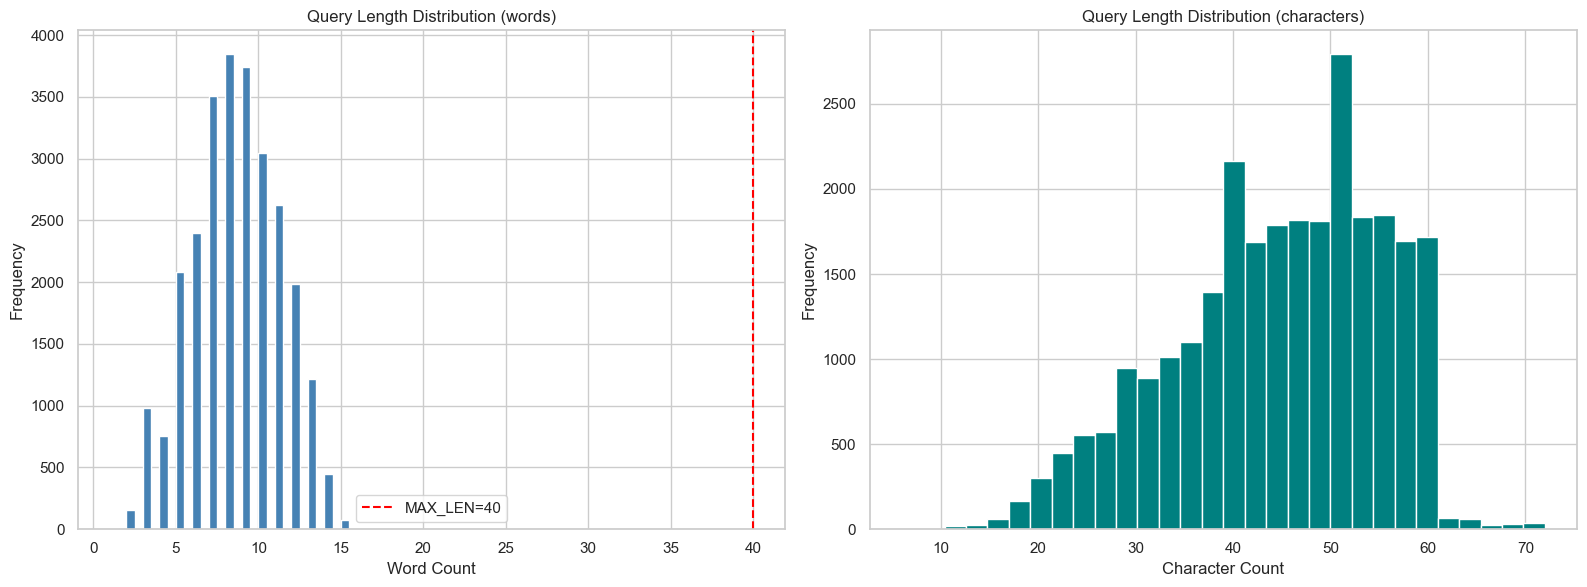

Word count — Mean: 8.4, Median: 8, Max: 16
Char count — Mean: 44.6, Median: 46, Max: 72

% of queries ≤ 40 words: 100.0%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word count distribution
axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(x=40, color="red", linestyle="--", label=f"MAX_LEN=40")
axes[0].set_title("Query Length Distribution (words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Character count distribution
axes[1].hist(df["char_count"], bins=30, color="teal", edgecolor="white")
axes[1].set_title("Query Length Distribution (characters)")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../artifacts/eval_results/query_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Word count — Mean: {df['word_count'].mean():.1f}, Median: {df['word_count'].median():.0f}, Max: {df['word_count'].max()}")
print(f"Char count — Mean: {df['char_count'].mean():.1f}, Median: {df['char_count'].median():.0f}, Max: {df['char_count'].max()}")
print(f"\n% of queries ≤ 40 words: {(df['word_count'] <= 40).mean()*100:.1f}%")

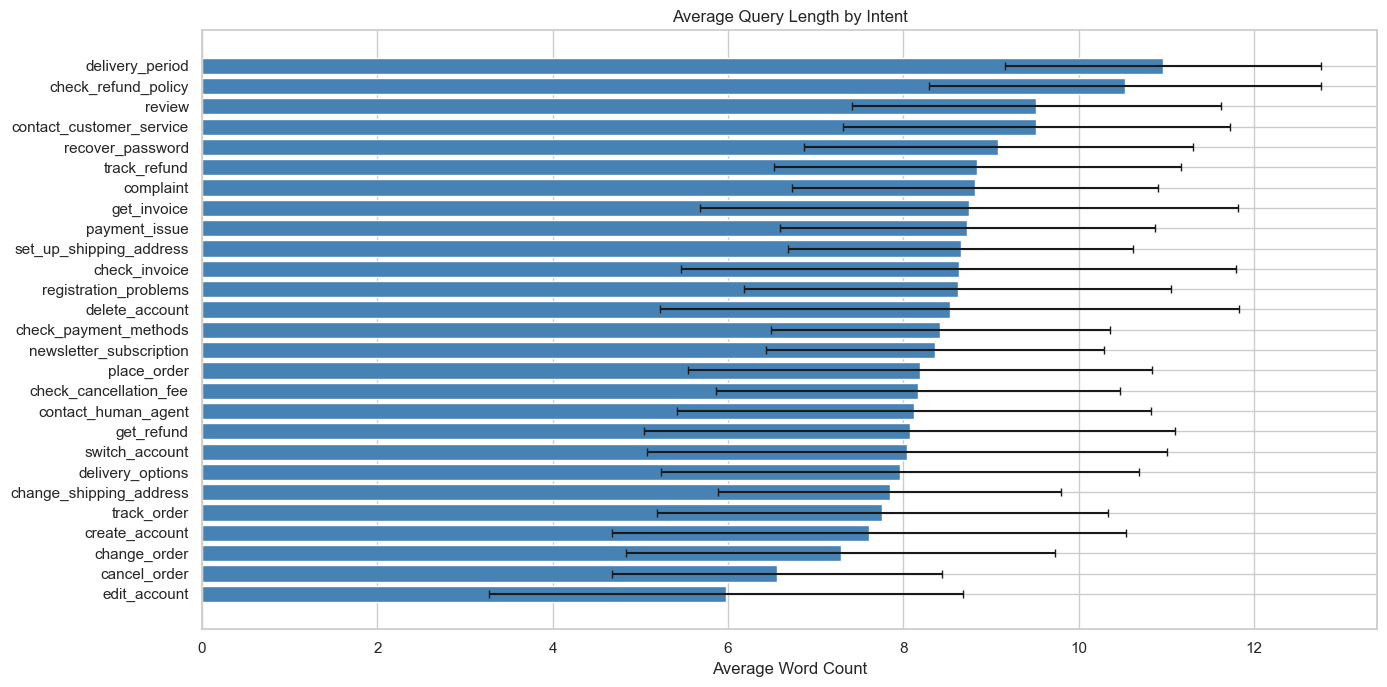

In [6]:
# Average query length by intent
intent_length = df.groupby("label")["word_count"].agg(["mean", "std", "median"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(intent_length.index[::-1], intent_length["mean"][::-1], 
        xerr=intent_length["std"][::-1], color="steelblue", capsize=3)
ax.set_xlabel("Average Word Count")
ax.set_title("Average Query Length by Intent")
plt.tight_layout()
plt.savefig("../artifacts/eval_results/query_length_by_intent.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Train / Val / Test Split Verification

Verify the stratified split preserves intent proportions across all sets.

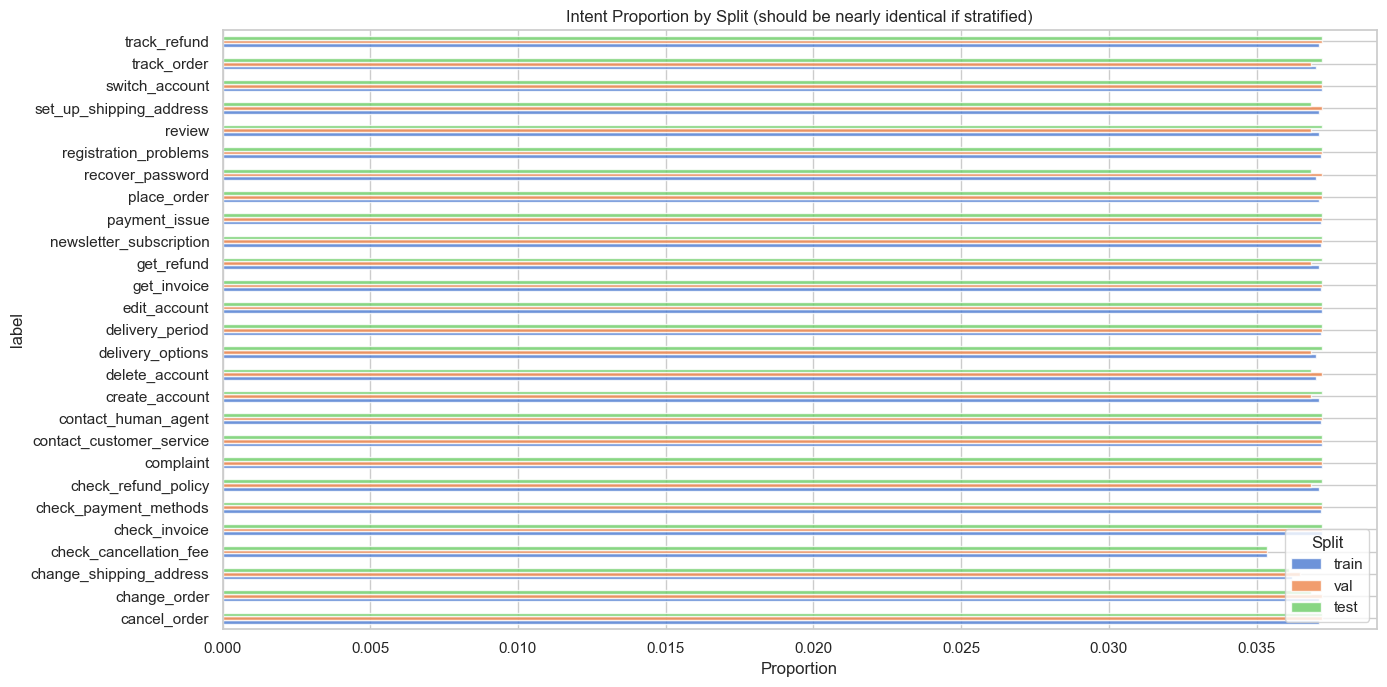

Max proportion deviation between splits: 0.0004
✅ Stratified split is balanced


In [7]:
train_df = pd.DataFrame(train)
val_df   = pd.DataFrame(val)
test_df  = pd.DataFrame(test)

split_props = pd.DataFrame({
    "train": train_df["label"].value_counts(normalize=True),
    "val":   val_df["label"].value_counts(normalize=True),
    "test":  test_df["label"].value_counts(normalize=True)
}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
split_props.plot(kind="barh", ax=ax, alpha=0.8)
ax.set_xlabel("Proportion")
ax.set_title("Intent Proportion by Split (should be nearly identical if stratified)")
ax.legend(title="Split")
plt.tight_layout()
plt.savefig("../artifacts/eval_results/split_proportions.png", dpi=150, bbox_inches="tight")
plt.show()

# Max deviation between splits
max_dev = (split_props.max(axis=1) - split_props.min(axis=1)).max()
print(f"Max proportion deviation between splits: {max_dev:.4f}")
print("✅ Stratified split is balanced" if max_dev < 0.02 else "⚠ Some imbalance detected")

## 6. Key Findings & Training Decisions

| Finding | Decision |
|---------|----------|
| 27 intent classes | Multi-class classification with BiGRU |
| Class imbalance present | Use inverse-frequency `class_weight` in `CrossEntropyLoss` |
| Most queries < 40 words | `MAX_LEN = 40` is appropriate |
| Stratified split preserves proportions | Train/Val/Test are representative |
| Some intents have similar phrasing | Monitor confusion matrix after training |